In [ ]:
# General load and data prep 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)


In [4]:
# Tenure groups
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 100],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs']
)

# Income quartiles (Q1 = lowest income, Q4 = highest)
df['IncomeQuartile'] = pd.qcut(df['MonthlyIncome'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

df[['Attrition', 'Attrition_Flag', 'YearsAtCompany', 'TenureGroup', 'MonthlyIncome', 'IncomeQuartile']].head()

,Attrition,Attrition_Flag,YearsAtCompany,TenureGroup,MonthlyIncome,IncomeQuartile
0,Yes,1,6,6-10 yrs,5993,Q3
1,No,0,10,6-10 yrs,5130,Q3
2,Yes,1,0,0-2 yrs,2090,Q1
3,No,0,8,6-10 yrs,2909,Q1
4,No,0,2,0-2 yrs,3468,Q2


In [5]:
for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'Gender']:
    rate = (df.groupby(col)['Attrition_Flag'].mean() * 100).round(1).sort_values(ascending=False)
    count = df.groupby(col)['Attrition_Flag'].count()
    summary = pd.DataFrame({'attrition_rate_%': rate, 'headcount': count}).sort_values('attrition_rate_%', ascending=False)
    print(f'--- {col} ---')
    print(summary)
    print()


--- Department ---
                        attrition_rate_%  headcount
Department                                         
Sales                              20.60        446
Human Resources                    19.00         63
Research & Development             13.80        961

--- JobRole ---
                           attrition_rate_%  headcount
JobRole                                               
Sales Representative                  39.80         83
Laboratory Technician                 23.90        259
Human Resources                       23.10         52
Sales Executive                       17.50        326
Research Scientist                    16.10        292
Healthcare Representative              6.90        131
Manufacturing Director                 6.90        145
Manager                                4.90        102
Research Director                      2.50         80

--- OverTime ---
          attrition_rate_%  headcount
OverTime                             
Yes  

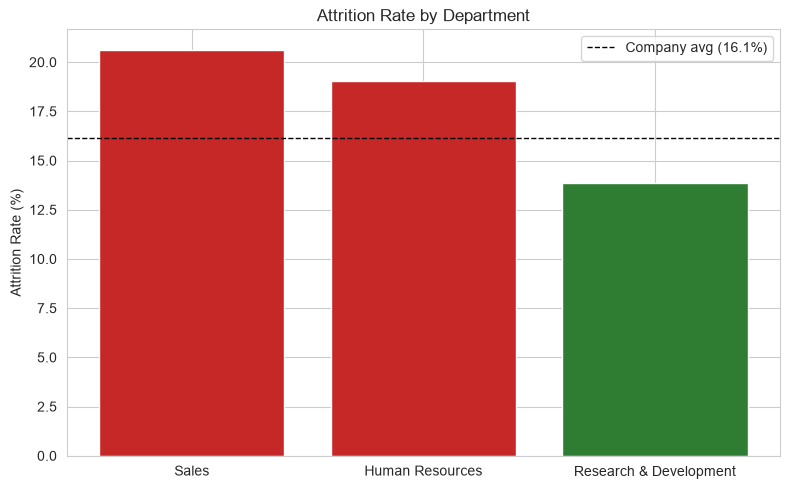

In [7]:
attrition_rate = df['Attrition_Flag'].mean()
fig, ax = plt.subplots(figsize=(8, 5))
dept_rate = (df.groupby('Department')['Attrition_Flag'].mean() * 100).sort_values(ascending=False)
colors = ['#C62828' if v > attrition_rate * 100 else '#2E7D32' for v in dept_rate.values]
ax.bar(dept_rate.index, dept_rate.values, color=colors)
ax.axhline(attrition_rate * 100, color='black', linestyle='--', linewidth=1, label=f'Company avg ({attrition_rate:.1%})')
ax.set_title('Attrition Rate by Department')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
tenure_summary = df.groupby('TenureGroup', observed=True).agg(
    headcount=('Attrition_Flag', 'count'),
    attritions=('Attrition_Flag', 'sum'),
    attrition_rate=('Attrition_Flag', 'mean')
)
tenure_summary['attrition_rate'] = (tenure_summary['attrition_rate'] * 100).round(1)
tenure_summary


,headcount,attritions,attrition_rate
TenureGroup,,,
0-2 yrs,342,102,29.80
3-5 yrs,434,60,13.80
6-10 yrs,448,55,12.30
11+ yrs,246,20,8.10


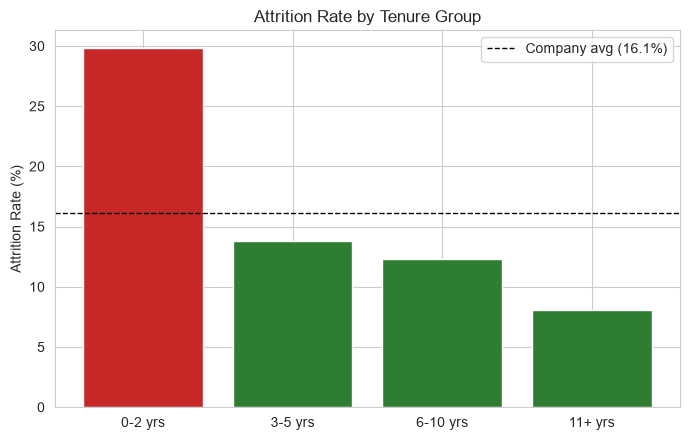

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs']
vals = tenure_summary.loc[order, 'attrition_rate']
colors = ['#C62828' if v > attrition_rate * 100 else '#2E7D32' for v in vals]
ax.bar(order, vals, color=colors)
ax.axhline(attrition_rate * 100, color='black', linestyle='--', linewidth=1, label=f'Company avg ({attrition_rate:.1%})')
ax.set_title('Attrition Rate by Tenure Group')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
income_summary = df.groupby('IncomeQuartile', observed=True).agg(
    headcount=('Attrition_Flag', 'count'),
    attritions=('Attrition_Flag', 'sum'),
    attrition_rate=('Attrition_Flag', 'mean'),
    income_range_min=('MonthlyIncome', 'min'),
    income_range_max=('MonthlyIncome', 'max'),
)
income_summary['attrition_rate'] = (income_summary['attrition_rate'] * 100).round(1)
income_summary

,headcount,attritions,attrition_rate,income_range_min,income_range_max
IncomeQuartile,,,,,
Q1,369,108,29.30,1009,2911
Q2,366,52,14.20,2926,4908
Q3,367,39,10.60,4930,8376
Q4,368,38,10.30,8380,19999


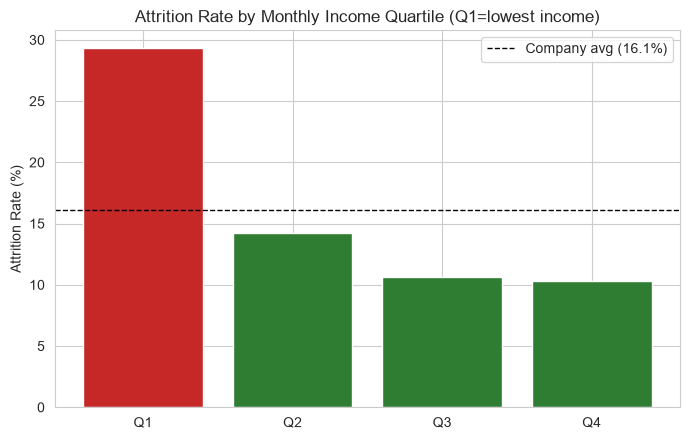

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
vals = income_summary['attrition_rate']
colors = ['#C62828' if v > attrition_rate * 100 else '#2E7D32' for v in vals]
ax.bar(income_summary.index, vals, color=colors)
ax.axhline(attrition_rate * 100, color='black', linestyle='--', linewidth=1, label=f'Company avg ({attrition_rate:.1%})')
ax.set_title('Attrition Rate by Monthly Income Quartile (Q1=lowest income)')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()
